# Setup

In [63]:
!pip uninstall torch_geometric -y
!pip install torch-scatter
!pip install torch-sparse
!pip install torch-cluster
!pip install torch-spline-conv
!pip install torch-geometric
!pip install dgl
!pip install torch-sparse -f https://data.pyg.org/whl/torch-2.2.1+cu121.html
!pip install torch_geometric
!pip install torch-sparse
import torch_sparse
import torch_geometric
from sklearn.preprocessing import LabelEncoder

# Preprocessing


In [64]:
import pandas as pd
# df1=pd.read_csv('SA02601_v6.csv')
parasite_feats=pd.read_csv('Host_Parasite_Data/parasites.csv')
P_phylum=LabelEncoder().fit(parasite_feats['phylum'])
P_genus=LabelEncoder().fit(parasite_feats['genus'])
P_species=LabelEncoder().fit(parasite_feats['species'])
parasite_feats['phylum']=P_phylum.transform(parasite_feats['phylum'])
parasite_feats['genus']=P_genus.transform(parasite_feats['genus'])
parasite_feats['species']=P_species.transform(parasite_feats['species'])
# print(parasite_feats)

host_feats=pd.read_csv('Host_Parasite_Data/hosttraits.csv')
H_genus=LabelEncoder().fit(host_feats['genus'])
H_species=LabelEncoder().fit(host_feats['species'])
host_feats['genus']=H_genus.transform(host_feats['genus'])
host_feats['species']=H_species.transform(host_feats['species'])

host_feats.index=host_feats['abbrev']
host_feats=host_feats.drop(['abbrev'],axis=1)
parasite_feats.index=parasite_feats['abbrev']
parasite_feats=parasite_feats.drop(['abbrev'],axis=1)

int_feats=pd.read_csv('Host_Parasite_Data/sevilletaData.csv')[['host_species','p_id','p_count']]
int_feats=int_feats[int_feats['host_species'].isin(list(host_feats.index))]
int_feats=int_feats[int_feats['p_id'].isin(list(parasite_feats.index))]

In [65]:
host_feats

,genus,species,adultmass,diet_breadth,gest_length,ind_homerange,litter_size,max_age,abund
abbrev,,,,,,,,,
chin,1,8,16.50,2,30.00,0.040000,4.50,36.0,86
dime,2,15,37.60,1,30.77,0.001600,5.40,24.0,1044
disp,2,20,125.00,4,23.49,0.000500,4.20,36.0,164
taqu,11,19,57.50,5,31.74,0.020000,4.00,96.0,31
neal,4,0,208.00,2,37.00,0.000200,2.50,92.4,356
nemi,4,16,255.00,5,34.00,0.000200,2.50,27.0,8
onar,5,1,30.00,6,30.50,0.020000,4.50,48.0,106
onle,5,10,27.90,4,31.65,0.010000,4.00,60.0,123
pgfl,6,5,9.21,2,25.50,0.000300,4.75,60.0,244


In [66]:
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture

temp = int_feats.groupby(['host_species','p_id'])[['p_count']].mean()
temp = temp[~temp['p_count'].isna()]
cnt_all=temp['p_count'].to_numpy()
cnt_all=cnt_all[~np.isnan(cnt_all)]
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(cnt_all.reshape(-1,1))
def all_plot_prob(interaction_data):
  p_interaction = gmm.predict_proba(np.array(interaction_data).reshape(-1,1))
#   print(p_interaction)
  return p_interaction[0]
edge_wt=pd.DataFrame(temp.groupby(['host_species','p_id'])['p_count'].apply(all_plot_prob))
# edge_wt.reset_index()
edge_wt

p_count
host_species p_id                                                   
amin         thbp  [0.9710405713078996, 0.0001471765288891118, 0....
chin         hede  [0.053128516486817275, 0.0037227283457164258, ...
             madi  [0.9686296446915346, 0.0001567856855788526, 0....
dime         caca  [0.906565523158171, 0.0004208892339933715, 0.0...
             ecga  [0.9710405713078996, 0.0001471765288891118, 0....
...                                                              ...
spsp         mocl  [0.9685008559040779, 0.00018610698834883657, 0...
             phma  [0.0006785779477490238, 0.0037844141087416128,...
             pras  [0.9685008559040779, 0.00018610698834883657, 0...
             ptdi  [0.9685008559040779, 0.00018610698834883657, 0...
             sype  [0.906565523158171, 0.0004208892339933715, 0.0...

[136 rows x 1 columns]

In [67]:
parasite_feats

,phylum,genus,species
abbrev,,,
ameu,0,0,28
anno,0,1,52
annu,0,1,53
asac,1,2,0
caca,1,3,13
...,...,...,...
thac,0,36,4
thbc,0,36,9
thbp,0,36,10


In [68]:
from torch_geometric.data import HeteroData
import torch_geometric.transforms as T
import torch
import numpy as np
data = HeteroData()# Save node indices:
data["host"].node_id = torch.arange(len(host_feats.index)).long()
data["parasite"].node_id = torch.arange(len(parasite_feats.index)).long()
temp=[]
host_map={}
for ind,i in enumerate(host_feats.index):
  data1=host_feats.loc[i].to_list()
  host_map[i]=ind
  temp.append(data1)
data["host"].x = torch.Tensor(temp)
# print(host_map)
temp=[]
parasite_map={}
for ind,i in enumerate(parasite_feats.index):
  data1=parasite_feats.loc[i].to_list()
  parasite_map[i]=ind
  temp.append(data1)
data["parasite"].x = torch.Tensor(temp)

# train_edge1=list(set(zip(list(edge_wt['VISSP_CODE']),list(edge_wt['PLTSP_CODE']))))

train_edge=[[parasite_map[v] for u,v in edge_wt.index],[host_map[u] for u,v in edge_wt.index]]
# print(torch.Tensor(train_edge).shape)
data["parasite", "attacks", "host"].edge_index = torch.Tensor(train_edge).long()
data["parasite", "attacks", "host"].edge_attr = torch.Tensor(np.array([list(i) for i in edge_wt['p_count'].to_numpy()]).astype(np.float64)).float()

data = T.ToUndirected()(data)

# GNN


In [69]:
from torch_geometric.loader import LinkNeighborLoader
transform = T.RandomLinkSplit(
#     num_val=0.1,
#     num_test=0.1,
#     disjoint_train_ratio=0.3,
    neg_sampling_ratio=1.0,
    add_negative_train_samples=True,
    edge_types=("parasite", "attacks", "host"),
    rev_edge_types=("host", "rev_attacks", "parasite"),
)
train_data, val_data, test_data = transform(data)

In [70]:
edge_label_index = train_data["parasite", "attacks", "host"].edge_label_index
edge_label = train_data["parasite", "attacks", "host"].edge_label
train_loader = LinkNeighborLoader(
    data=train_data,
    num_neighbors=[5, 2],
#     neg_sampling_ratio=2.0,
    edge_label_index=(("parasite", "attacks", "host"), edge_label_index),
    edge_label=edge_label,
    batch_size=128,
    shuffle=True,
)

/home/arka/.local/lib/python3.10/site-packages/torch_geometric/sampler/neighbor_sampler.py:61: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  warnings.warn(f"Using '{self.__class__.__name__}' without a "


In [71]:
edge_label_index = val_data["parasite", "attacks", "host"].edge_label_index
edge_label = val_data["parasite", "attacks", "host"].edge_label
val_loader = LinkNeighborLoader(
    data=val_data,
    num_neighbors=[5, 2],
#     neg_sampling_ratio=2.0,
    edge_label_index=(("parasite", "attacks", "host"), edge_label_index),
    edge_label=edge_label,
    batch_size=128,
    shuffle=True,
)

In [14]:
edge_label_index = test_data["parasite", "attacks", "host"].edge_label_index
edge_label = test_data["parasite", "attacks", "host"].edge_label
test_loader = LinkNeighborLoader(
    data=test_data,
    num_neighbors=[5, 2],
#     neg_sampling_ratio=2.0,
    edge_label_index=(("parasite", "attacks", "host"), edge_label_index),
    edge_label=edge_label,
    batch_size=128,
    shuffle=True,
)

In [88]:
from torch_geometric.nn import SAGEConv, to_hetero
import torch.nn.functional as F
import torch.nn as nn
from torch import Tensor
class GNN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        self.conv1 = SAGEConv(hidden_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
    def forward(self, x: Tensor, edge_index: Tensor) -> Tensor:
        x = self.conv1(x, edge_index)
        x = F.leaky_relu(x)
        x = self.conv2(x, edge_index)
        return x
# Our final classifier applies the dot-product between source and destination
# node embeddings to derive edge-level predictions:
class Classifier(torch.nn.Module):
    def forward(self, x_visitor: Tensor, x_host: Tensor, edge_label_index: Tensor) -> Tensor:
        # Convert node embeddings to edge-level representations:
        edge_feat_visitor = x_visitor[edge_label_index[0]]
        edge_feat_host = x_host[edge_label_index[1]]
        # Apply dot-product to get a prediction per supervision edge:
        return (edge_feat_visitor * edge_feat_host).sum(dim=-1)

class EdgeClassifier(torch.nn.Module):
    def __init__(self, hidden_channels,embedding_size):
        super().__init__()
        self.fc1 = nn.Linear(embedding_size*2, hidden_channels)

        # Non-linearity
        self.sigmoid1 = nn.Sigmoid()

        # Linear function (readout)
#         self.fc2 = nn.Linear(128, 128)
#         self.sigmoid2 = nn.Sigmoid()
        self.fc3 = nn.Linear(hidden_channels, 3)

    def forward(self, x_visitor: Tensor, x_host: Tensor, edge_label_index: Tensor) -> Tensor:
        # Convert node embeddings to edge-level representations:
        edge_feat_visitor = x_visitor[edge_label_index[0]]
        edge_feat_host = x_host[edge_label_index[1]]
#         print(edge_feat_visitor.shape,edge_feat_host.shape,.shape)
        edge_feats=torch.cat((edge_feat_visitor,edge_feat_host),1)
#         print(edge_feats.shape)
        x=self.fc1(edge_feats)
        x=self.sigmoid1(x)
#         x=self.fc2(x)
#         x=self.sigmoid2(x)
        x=self.fc3(x)
        return x

class Model(torch.nn.Module):
    def __init__(self, hidden_channels,embedding_size):
        super().__init__()
        # Since the dataset does not come with rich features, we also learn two
        # embedding matrices for users and movies:
        self.host_lin = torch.nn.Linear(9, embedding_size)
        self.visitor_lin = torch.nn.Linear(3, embedding_size)
        self.visitor_emb = torch.nn.Embedding(data["parasite"].num_nodes, embedding_size)
        self.host_emb = torch.nn.Embedding(data["host"].num_nodes, embedding_size)
        # Instantiate homogeneous GNN:
        self.gnn = GNN(embedding_size)
        # Convert GNN model into a heterogeneous variant:
        self.gnn = to_hetero(self.gnn, metadata=data.metadata())
        self.classifier = Classifier()
        self.edgeclassifier = EdgeClassifier(hidden_channels,embedding_size)
    def forward(self, data: HeteroData) -> Tensor:
        x_dict = {
          "parasite": self.visitor_emb(data["parasite"].node_id)+ self.visitor_lin(data["parasite"].x.float()),
          "host": self.host_lin(data["host"].x) + self.host_emb(data["host"].node_id),
        }
        # `x_dict` holds feature matrices of all node types
        # `edge_index_dict` holds all edge indices of all edge types
#         print(x_dict)
        x_dict = self.gnn(x_dict, data.edge_index_dict)
#         print(x_dict)
        pred2 = self.edgeclassifier(
            x_dict["parasite"],
            x_dict["host"],
            data["parasite", "attacks", "host"].edge_label_index,
        )
        pred = self.classifier(
            x_dict["parasite"],
            x_dict["host"],
            data["parasite", "attacks", "host"].edge_label_index,
        )
#         print(pred)
        return pred,pred2

model = Model(hidden_channels=256,embedding_size=17)

In [93]:
import tqdm
import torch.nn.functional as F
from torch.nn import MSELoss
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: '{device}'")
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
train_loss=[]
val_loss=[]
for epoch in range(1, 100):
    total_loss = total_examples = 0
    for sampled_data in tqdm.tqdm(train_loader):

        optimizer.zero_grad()
        sampled_data.to(device)
        pred,pred2 = model(sampled_data)
#         print(pred2)
#         pred=torch.nan_to_num(pred)
#         print(sampled_data)

        ground_truth_1 = sampled_data["parasite", "attacks", "host"].edge_label.float()
        ground_truth_2 = sampled_data["parasite", "attacks", "host"].edge_attr
#         print(max(sampled_data["parasite", "attacks", "host"].edge_label_index[0]),max(sampled_data["parasite", "attacks", "host"].edge_label_index[1]))
#         print(max(sampled_data["parasite", "attacks", "host"].edge_index[0]),max(sampled_data["parasite", "attacks", "host"].edge_index[1]))
        L1 = F.binary_cross_entropy_with_logits(pred, ground_truth_1)
        temp=[]
#         print(sampled_data["parasite", "attacks", "host"].edge_index,sampled_data["parasite", "attacks", "host"].edge_label_index)

        for u,v in zip(sampled_data["parasite", "attacks", "host"].edge_label_index[0],sampled_data["parasite", "attacks", "host"].edge_label_index[1]):
                flag=True
                for ind,uv in enumerate(zip(sampled_data["parasite", "attacks", "host"].edge_index[0],sampled_data["parasite", "attacks", "host"].edge_index[1])):
                    u1,v1=uv
                    if(u1==u and v1==v):
                        temp.append(ground_truth_2[ind].tolist())
                        flag=False
                        break
                if(flag):
                    temp.append([0.0,0.0,0.0])

#         print(ind1)
        ground_truth_2=torch.Tensor(temp)
#         print(ground_truth_1.shape,ground_truth_2.shape)
#         print(pred.shape,pred2.shape)
        L2 = F.mse_loss(pred2, ground_truth_2)
        loss=L1+L2
        train_loss.append(loss)
#         VAL LOSS


#         loss = MSELoss(pred, ground_truth)
        loss.backward()
        optimizer.step()
        total_loss += float(loss) * pred.numel()
        total_examples += pred.numel()
#         break
    total_loss_val = total_examples_val = 0
    for sampled_data in tqdm.tqdm(val_loader):
        pred,pred2 = model(sampled_data)
        ground_truth_1 = sampled_data["parasite", "attacks", "host"].edge_label.float()
        ground_truth_2 = sampled_data["parasite", "attacks", "host"].edge_attr
        L1 = F.binary_cross_entropy_with_logits(pred, ground_truth_1)
        temp=[]
        for u,v in zip(sampled_data["parasite", "attacks", "host"].edge_label_index[0],sampled_data["parasite", "attacks", "host"].edge_label_index[1]):
                flag=True
                for ind,uv in enumerate(zip(sampled_data["parasite", "attacks", "host"].edge_index[0],sampled_data["parasite", "attacks", "host"].edge_index[1])):
                    u1,v1=uv
                    if(u1==u and v1==v):
                        temp.append(ground_truth_2[ind].tolist())
                        flag=False
                        break
                if(flag):
                    temp.append([0.0,0.0,0.0])
        ground_truth_2=torch.Tensor(temp)
        L2 = F.mse_loss(pred2, ground_truth_2)
        loss=L1+L2
        total_loss_val += float(loss) * pred.numel()
        total_examples_val += pred.numel()
#         VAL LOSS
        val_loss.append(total_loss_val/total_examples_val)
    torch.save(model.state_dict(), 'HPmodel_'+str(epoch+1)+'.pth')
    print(f"Epoch: {epoch:03d}, Loss: {total_loss / total_examples:.4f}, Val Loss: {total_loss_val/total_examples_val:.4f}")

Device: 'cpu'


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00, 31.21it/s]


Epoch: 001, Loss: 1.6888, Val Loss: 8.8772


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00, 30.34it/s]


Epoch: 002, Loss: 1.3763, Val Loss: 10.5021


...

Epoch: 097, Loss: 1.1483, Val Loss: 9.6297


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00, 36.57it/s]


Epoch: 098, Loss: 0.4265, Val Loss: 12.1579


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00, 36.54it/s]

Epoch: 099, Loss: 0.5900, Val Loss: 9.6794


1


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00, 70.63it/s]

(54,)
[0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 1. 1. 0. 1. 0. 1. 1. 1.
 0. 1. 1. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 1. 0. 1. 1. 0. 0. 1. 0. 1. 0.
 1. 1. 1. 1. 1. 1.]

Validation AUROC: 0.8518518518518517
Validation AUPRC: 0.8212560386473429


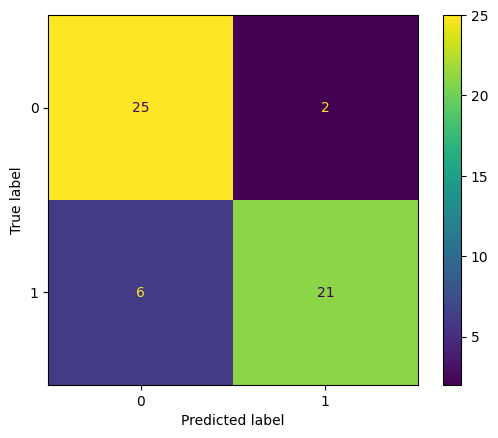

In [105]:
from sklearn.metrics import roc_auc_score,average_precision_score
import numpy as np
import tqdm
import torch.nn.functional as F
from torch.nn import MSELoss
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
model.load_state_dict(torch.load('HPmodel_299_256_17.pth'))
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(f"Device: '{device}'")
# model = model.to(device)
preds = []
ground_truths = []
print(len(test_loader))
for sampled_data in tqdm.tqdm(test_loader):
    with torch.no_grad():
        sampled_data.to(device)
#         print(sampled_data["visitor",'visits','plant'].edge_label)
        preds.append(model(sampled_data)[0])
        ground_truths.append(sampled_data["parasite",'attacks','host'].edge_label)
pred = torch.cat(preds, dim=0).cpu().numpy()
print(pred.shape)
ground_truth = torch.cat(ground_truths, dim=0).cpu().numpy()
pred=np.nan_to_num(pred)
temp=pred
temp=[0 if i <0 else 1 for i in temp]
pred=temp
print(ground_truth)
cm = confusion_matrix(ground_truth, pred)
ConfusionMatrixDisplay(cm).plot()
auc = roc_auc_score(ground_truth, pred)
auc1 = average_precision_score(ground_truth, pred)
print()
print(f"Validation AUROC: {auc}")
print(f"Validation AUPRC: {auc1}")